# Problem Definition

## Latar Belakang

Kebakaran hutan dan lahan (Karhutla) merupakan salah satu bencana lingkungan yang paling merusak dan terjadi secara berulang setiap musim kemarau. Fenomena ini tidak hanya mengancam kelestarian ekosistem, tetapi juga berdampak langsung pada kesehatan masyarakat, aktivitas ekonomi, hingga stabilitas iklim regional. Di Indonesia sendiri, Karhutla menjadi masalah kronis yang membutuhkan pendekatan deteksi dini yang lebih efektif dan responsif.

Pemantauan konvensional seperti pengawasan langsung oleh petugas atau penggunaan citra satelit masih memiliki keterbatasan dalam hal kecepatan dan cakupan area. Oleh karena itu, pendekatan berbasis kecerdasan buatan—khususnya machine learning—menjadi solusi yang menjanjikan untuk mempercepat proses deteksi dan meningkatkan akurasi prediksi kebakaran.

## Masalah

Masalah utama yang dihadapi adalah bagaimana membangun sistem yang mampu mengidentifikasi potensi kejadian kebakaran hutan secara otomatis dan akurat berdasarkan data meteorologi yang tersedia. Data seperti suhu udara, kelembaban, curah hujan, indeks kebakaran, dan variabel lingkungan lainnya memiliki pola yang kompleks dan tidak selalu linier, sehingga membutuhkan pendekatan modelling yang tepat.

## Tujuan

Tujuan dari proyek ini adalah:

1. Mengembangkan model machine learning yang mampu melakukan klasifikasi status kebakaran hutan (terjadi atau tidak terjadi) berdasarkan data meteorologi
2. Mengevaluasi dan membandingkan performa beberapa algoritma klasifikasi untuk menentukan model terbaik
3. Menyediakan dasar analisis yang dapat dikembangkan lebih lanjut menjadi sistem peringatan dini Karhutla

# Data Collection

## Sumber Dataset

Dataset yang digunakan dalam proyek ini adalah **Extended Algerian Forest Fires Dataset** dari UCI Machine Learning Repository. Dataset ini dikumpulkan dari wilayah Bejaia, Algeria selama periode musim panas tahun 2021, mulai dari Juni hingga September.

## Deskripsi Dataset

Dataset ini terdiri dari **1.215 observasi harian** dengan **13 variabel** yang mencakup pengukuran meteorologi dan indeks kebakaran hutan. Setiap baris merepresentasikan kondisi cuaca pada satu hari tertentu beserta status terjadinya kebakaran.

## Fitur Dataset

| No | Nama Fitur | Deskripsi |
|----|-----------|----------|
| 1 | DATE | Tanggal pengamatan |
| 2 | Temperature | Suhu udara dalam Celcius (°C) |
| 3 | Ws | Kecepatan angin dalam km/h |
| 4 | Rain | Curah hujan dalam mm |
| 5 | RH | Kelembaban relatif dalam persen (%) |
| 6 | FFMC | Fine Fuel Moisture Code — indeks kelembaban bahan bakar halus |
| 7 | DMC | Duff Moisture Code — indeks kelembaban lapisan organik |
| 8 | DC | Drought Code — indeks kekeringan |
| 9 | ISI | Initial Spread Index — indeks potensi penyebaran api |
| 10 | BUI | Build-Up Index — indeks akumulasi bahan bakar |
| 11 | FWI | Fire Weather Index — indeks kondisi cuaca kebakaran |
| 12 | Classes | Label kelas: fire atau not fire (target variabel) |
| 13 | Bejaia 2021 | Informasi lokasi dan tahun pengamatan |

## Proses Pengambilan Data

Data diambil dari file Excel (`.xlsx`) menggunakan library `pandas` dengan fungsi `read_excel()`.

In [1]:
import pandas as pd
from pathlib import Path

# Deteksi akar repositori secara otomatis (aman dijalankan dari direktori mana pun)
repo_root = Path.cwd()
while not (repo_root / 'data').is_dir():
    repo_root = repo_root.parent

df = pd.read_excel(repo_root / 'data' / 'raw' / 'algerian_forest_fires.xlsx')
print(f'Dataset berhasil dimuat:')
df.head()

Dataset berhasil dimuat:


,DATE,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Bejaia 2021
0,2021-06-01 00:00:00,27,13,2.1,59,63.6,5.2,8.3,1.0,5.0,0.4,not fire,Bejaia 2021
1,2021-06-02 00:00:00,24,10,0.3,72,55.1,4.1,7.7,0.5,4.0,0.2,not fire,Bejaia 2021
2,2021-06-03 00:00:00,27,11,3.0,76,47.1,3.0,8.3,0.2,3.2,0.1,not fire,Bejaia 2021
3,2021-06-04 00:00:00,28,9,1.0,70,52.3,3.1,8.4,0.3,3.2,0.1,not fire,Bejaia 2021
4,2021-06-05 00:00:00,28,11,0.1,64,73.4,4.5,16.9,1.6,5.4,0.7,not fire,Bejaia 2021


# Eksplorasi Data Awal (EDA Awal)

Tahap ini bertujuan untuk memahami karakteristik dasar dataset sebelum masuk ke analisis mendalam. Fokus utama adalah mengidentifikasi karaktersitik data, serta kualitas data yang perlu dibersihkan.

## 1. Inspeksi Struktur Data

In [2]:
print('=== DIMENSI DATA ===')
print(f'Baris: {df.shape[0]}, Kolom: {df.shape[1]}')
print('\n=== TIPE DATA PER KOLOM ===')
print(df.dtypes)
print('\n=== INFO LENGKAP ===')
df.info()

=== DIMENSI DATA ===
Baris: 1215, Kolom: 13

=== TIPE DATA PER KOLOM ===
DATE            object
Temperature      int64
        Ws       int64
    Rain       float64
RH               int64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
Bejaia 2021     object
dtype: object

=== INFO LENGKAP ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE         1215 non-null   object 
 1   Temperature  1215 non-null   int64  
 2           Ws   1215 non-null   int64  
 3       Rain     1215 non-null   float64
 4   RH           1215 non-null   int64  
 5   FFMC         1215 non-null   float64
 6   DMC          1215 non-null   float64
 7   DC           1215 non-null   float64
 8   ISI          1215 non-null   float64
 9   BUI          1215 

## 2. Pemeriksaan Kualitas Data

In [3]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== MISSING VALUES ===
DATE           0
Temperature    0
        Ws     0
    Rain       0
RH             0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Bejaia 2021    0
dtype: int64

Total missing values: 0


In [4]:
print('=== DUPLIKAT ===')
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')

=== DUPLIKAT ===
Jumlah baris duplikat: 0


In [5]:
print('=== NAMA KOLOM (RAW) ===')
for i, col in enumerate(df.columns):
    print(f'{i}: {repr(col)}')

=== NAMA KOLOM (RAW) ===
0: 'DATE'
1: 'Temperature'
2: '        Ws'
3: '    Rain'
4: 'RH'
5: 'FFMC'
6: 'DMC'
7: 'DC'
8: 'ISI'
9: 'BUI'
10: 'FWI'
11: 'Classes'
12: 'Bejaia 2021'


In [6]:
print('=== DISTRIBUSI KELAS TARGET ===')
print(df['Classes'].value_counts())
print(f'\nJumlah kelas unik: {df["Classes"].nunique()}')

=== DISTRIBUSI KELAS TARGET ===
Classes
fire        613
not fire    582
fire         20
Name: count, dtype: int64

Jumlah kelas unik: 3


In [7]:
print('=== DISTRIBUSI REGION ===')
print(df['Bejaia 2021'].value_counts())

=== DISTRIBUSI REGION ===
Bejaia 2021
Bejaia 2021           122
Blida 2021            122
Bouira 2021           122
Tipaza2017            122
Setif 2021            122
Tiaret 2021           122
Sidi-Bel-Abass2012    122
Bejaia_2012           122
Tizi-Ouzou2021        122
Khenchela 2021        117
Name: count, dtype: int64


## Pemeriksaan Duplikat Silang-Region

Dataset menggabungkan data dari **10 region berbeda**. Perlu dicek apakah ada baris yang identik pada fitur numerik antar region, yang bisa menyebabkan data leakage saat train-test split.

In [8]:
# Cek duplikat berdasarkan semua kolom kecuali Classes
feature_cols = [c for c in df.columns if c != 'Classes']

# Cari baris duplikat berdasarkan fitur
dup_mask = df.duplicated(subset=feature_cols, keep=False)
n_dup = df.duplicated(subset=feature_cols, keep='first').sum()

print('=== DUPLIKAT SILANG-REGION ===')
print(f'Jumlah baris yang memiliki fitur identik: {dup_mask.sum()}')
print(f'Jumlah duplikat (dihitung sekali): {n_dup}')

if n_dup > 0:
    print(f'\nContoh duplikat (5 baris pertama):')
    dup_rows = df[dup_mask].sort_values(by=feature_cols)
    display(dup_rows.head(10))
else:
    print('\nTidak ditemukan duplikat.')

=== DUPLIKAT SILANG-REGION ===
Jumlah baris yang memiliki fitur identik: 0
Jumlah duplikat (dihitung sekali): 0

Tidak ditemukan duplikat.


In [9]:
# Cek apakah ada duplikat dengan label BERBEDA (konflik)
if n_dup > 0:
    dup_rows = df[dup_mask].copy()
    
    # Kelompokkan berdasarkan fitur, cek apakah label berbeda
    grouped = dup_rows.groupby(feature_cols)['Classes'].nunique()
    conflict = grouped[grouped > 1]
    
    print('=== ANALISIS KONFLIK LABEL ===')
    if len(conflict) > 0:
        print(f'Ditemukan {len(conflict)} kelompok duplikat dengan LABEL BERBEDA!')
        print('\nBaris-baris yang konflik:')
        conflict_idx = []
        for vals, _ in conflict.items():
            mask = True
            for col, val in zip(feature_cols, vals):
                mask = mask & (df[col] == val)
            conflict_rows = df[mask]
            conflict_idx.extend(conflict_rows.index.tolist())
            display(conflict_rows)
        print(f'\nIndeks baris konflik: {conflict_idx}')
    else:
        print('Semua duplikat memiliki label yang SAMA (tidak ada konflik).')
else:
    print('Tidak ada duplikat untuk dianalisis.')

Tidak ada duplikat untuk dianalisis.


## 3. Identifikasi Masalah yang Perlu Dibersihkan

Berdasarkan pemeriksaan di atas, ditemukan beberapa masalah kualitas data:

| No | Masalah | Kolom | Dampak |
|----|---------|-------|--------|
| 1 | Karakter kutip tunggal (`'`) dan whitespace dalam nama kolom | Semua kolom | Kesalahan akses kolom |
| 2 | 3 kelas unik (seharusnya 2) | `Classes` | Duplikasi kelas akibat whitespace |
| 3 | DATE bertipe object | `DATE` | Tidak bisa dilakukan operasi tanggal |
| 4 | Penamaan region tidak konsisten | `Bejaia 2021` | Kesulitan filtering/gruping |

## 4. Statistik Deskriptif

In [10]:
print('=== STATISTIK DESKRIPTIF NUMERIK ===')
df.describe()

=== STATISTIK DESKRIPTIF NUMERIK ===


,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,33.331687,16.598354,0.401893,52.925103,83.276379,26.275144,78.132181,9.904527,28.776049,15.497366
std,4.044168,5.744132,1.421008,19.883064,13.288328,22.505102,65.917867,11.244088,23.745075,15.967834
min,21.000000,5.000000,0.000000,11.000000,22.500000,0.200000,0.000000,0.000000,0.300000,0.000000
25%,31.000000,13.000000,0.000000,37.000000,79.800000,10.000000,25.400000,2.500000,10.850000,3.200000
50%,33.000000,15.000000,0.000000,53.000000,87.500000,18.600000,59.000000,6.700000,21.000000,11.100000
75%,36.000000,18.000000,0.100000,69.000000,91.900000,36.600000,111.800000,12.600000,40.600000,21.750000
max,43.000000,50.000000,20.200000,96.000000,98.600000,113.900000,308.200000,116.700000,113.800000,102.500000


In [11]:
print('=== STATISTIK DESKRIPTIF KATEGORIKAL ===')
df.describe(include='object')

=== STATISTIK DESKRIPTIF KATEGORIKAL ===


,DATE,Classes,Bejaia 2021
count,1215,1215,1215
unique,372,3,10
top,2021-09-26 00:00:00,fire,Bejaia 2021
freq,7,613,122


## 5. Identifikasi Distribusi & Potensi Outliers

In [12]:
print('=== ANALISIS DISTRIBUSI DATA NUMERIK ===')
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: min={df[col].min()}, max={df[col].max()}, IQR={iqr:.2f}, outliers={outliers}')

=== ANALISIS DISTRIBUSI DATA NUMERIK ===
Temperature: min=21, max=43, IQR=5.00, outliers=10
        Ws: min=5, max=50, IQR=5.00, outliers=108
    Rain: min=0.0, max=20.2, IQR=0.10, outliers=248
RH: min=11, max=96, IQR=32.00, outliers=0
FFMC: min=22.5, max=98.6, IQR=12.10, outliers=104
DMC: min=0.2, max=113.9, IQR=26.60, outliers=52


DC: min=0.0, max=308.2, IQR=86.40, outliers=27


ISI: min=0.0, max=116.7, IQR=10.10, outliers=84
BUI: min=0.3, max=113.8, IQR=29.75, outliers=41
FWI: min=0.0, max=102.5, IQR=18.55, outliers=58


## 6. Kesimpulan EDA Awal

Berdasarkan hasil eksplorasi awal, berikut adalah ringkasan temuan:

### Kondisi Dataset
- Dataset memiliki **1.215 baris** dan **13 kolom** dengan campuran tipe numerik (10 kolom) dan kategorikal (3 kolom)
- Tidak ditemukan **missing values** maupun **baris duplikat**
- Data mencakup periode **Juni hingga September 2021** dari **10 region** di Algeria

### Masalah Kualitas Data yang Ditemukan

| No | Masalah | Prioritas |
|----|---------|----------|
| 1 | **Nama kolom tidak bersih** — terdapat karakter kutip tunggal (`'`) dan whitespace berlebih pada kolom `Ws` dan `Rain` | Tinggi |
| 2 | **Kelas target duplikat** — `Classes` memiliki 3 unique values (seharusnya 2), disebabkan oleh whitespace pada nilai kelas | Tinggi |
| 3 | **Tipe DATE belum sesuai** — kolom tanggal masih bertipe `object`, perlu dikonversi ke `datetime` | Sedang |
| 4 | **Penamaan region tidak konsisten** — ada yang menggunakan spasi (`Bejaia 2021`) dan underscore (`Bejaia_2012`), serta tahun berbeda (2012, 2017, 2021) | Rendah |
| 5 | **Potensi outlier** — beberapa kolom seperti `Ws` dan `FWI` memiliki nilai maksimum yang jauh dari kuartil ketiga | Rendah |

### Statistik Ringkasan
- **Suhu rata-rata**: 33.3°C (rentang 21–43°C)
- **Kelembaban rata-rata**: 52.9% (rentang 11–96%)
- **Curah hujan**: sebagian besar bernilai 0 (75% data tidak ada hujan)
- **Distribusi kelas**: sedikit imbalanced — fire (52.1%) vs not fire (47.9%)

### Langkah Selanjutnya
Tahap berikutnya adalah **Data Cleaning** untuk menyelesaikan masalah-masalah yang telah teridentifikasi di atas.

# Data Cleaning

Tahap ini bertujuan untuk memperbaiki masalah kualitas data yang telah teridentifikasi pada EDA Awal, sehingga data siap digunakan untuk analisis lebih lanjut dan pemodelan.

Masalah yang akan diperbaiki:
1. Nama kolom mengandung whitespace dan karakter kutip tunggal
2. Kolom `Classes` memiliki 3 unique values (seharusnya 2) akibat whitespace
3. Kolom `DATE` dan `Bejaia 2021` tidak relevan untuk prediksi berbasis meteorologi — akan di-drop

## 1. Bersihkan Nama Kolom

In [13]:
print('=== NAMA KOLOM SEBELUM BERSIH ===')
for i, col in enumerate(df.columns):
    print(f'{i}: {repr(col)}')

# Bersihkan whitespace dan karakter kutip tunggal dari nama kolom
df.columns = df.columns.str.strip().str.strip("'").str.strip()

print('\n=== NAMA KOLOM SESUDAH BERSIH ===')
for i, col in enumerate(df.columns):
    print(f'{i}: {repr(col)}')

=== NAMA KOLOM SEBELUM BERSIH ===
0: 'DATE'
1: 'Temperature'
2: '        Ws'
3: '    Rain'
4: 'RH'
5: 'FFMC'
6: 'DMC'
7: 'DC'
8: 'ISI'
9: 'BUI'
10: 'FWI'
11: 'Classes'
12: 'Bejaia 2021'

=== NAMA KOLOM SESUDAH BERSIH ===
0: 'DATE'
1: 'Temperature'
2: 'Ws'
3: 'Rain'
4: 'RH'
5: 'FFMC'
6: 'DMC'
7: 'DC'
8: 'ISI'
9: 'BUI'
10: 'FWI'
11: 'Classes'
12: 'Bejaia 2021'


## 2. Normalisasi Kolom Target (`Classes`)

In [14]:
print('=== UNIQUE VALUES SEBELUM BERSIH ===')
print(df['Classes'].unique())
print(f'Jumlah: {df["Classes"].nunique()}')

# Bersihkan whitespace pada nilai kelas
df['Classes'] = df['Classes'].str.strip()

print('\n=== UNIQUE VALUES SESUDAH BERSIH ===')
print(df['Classes'].unique())
print(f'Jumlah: {df["Classes"].nunique()}')

print('\n=== DISTRIBUSI KELAS SESUDAH BERSIH ===')
print(df['Classes'].value_counts())

=== UNIQUE VALUES SEBELUM BERSIH ===
['not fire' 'fire' 'fire ']
Jumlah: 3

=== UNIQUE VALUES SESUDAH BERSIH ===
['not fire' 'fire']
Jumlah: 2

=== DISTRIBUSI KELAS SESUDAH BERSIH ===
Classes
fire        633
not fire    582
Name: count, dtype: int64


## 3. Drop Kolom yang Tidak Diperlukan

Kolom yang di-drop:
- `DATE` — tidak relevan untuk prediksi berbasis meteorologi
- `Bejaia 2021` — region tidak relevan agar model bersifat generalizable

In [15]:
print('=== KOLOM SEBELUM DROP ===')
print(f'Jumlah kolom: {len(df.columns)}')
print(list(df.columns))

# Drop kolom DATE dan Bejaia 2021
df.drop(columns=['DATE', 'Bejaia 2021'], inplace=True)

print('\n=== KOLOM SESUDAH DROP ===')
print(f'Jumlah kolom: {len(df.columns)}')
print(list(df.columns))

=== KOLOM SEBELUM DROP ===
Jumlah kolom: 13
['DATE', 'Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']

=== KOLOM SESUDAH DROP ===
Jumlah kolom: 11
['Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']


## 4. Hapus Duplikat

Berdasarkan pemeriksaan di EDA Awal, ditemukan baris dengan fitur identik antar region. Baris duplikat dihapus untuk mencegah data leakage saat train-test split.

In [16]:
print('=== SEBELUM DEDUPLIKASI ===')
print(f'Jumlah baris: {len(df)}')

# Hitung duplikat berdasarkan fitur (kecuali Classes)
feature_cols = [c for c in df.columns if c != 'Classes']
n_before = len(df)
n_dup = df.duplicated(subset=feature_cols).sum()
print(f'Jumlah duplikat: {n_dup}')

# Hapus duplikat
df = df.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)

print(f'\n=== SESUDAH DEDUPLIKASI ===')
print(f'Jumlah baris: {len(df)}')
print(f'Baris dihapus: {n_before - len(df)}')
print(f'\nDistribusi kelas setelah deduplikasi:')
print(df['Classes'].value_counts())

=== SEBELUM DEDUPLIKASI ===
Jumlah baris: 1215
Jumlah duplikat: 27

=== SESUDAH DEDUPLIKASI ===
Jumlah baris: 1188
Baris dihapus: 27

Distribusi kelas setelah deduplikasi:
Classes
fire        619
not fire    569
Name: count, dtype: int64


## 5. Verifikasi Hasil Cleaning

In [17]:
print('=== DIMENSI DATA AKHIR ===')
print(f'Baris: {df.shape[0]}, Kolom: {df.shape[1]}')

print('\n=== TIPE DATA PER KOLOM ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

print('\n=== DISTRIBUSI KELAS TARGET ===')
print(df['Classes'].value_counts())

print('\n=== 5 BARIS PERTAMA ===')
df.head()

=== DIMENSI DATA AKHIR ===
Baris: 1188, Kolom: 11

=== TIPE DATA PER KOLOM ===
Temperature      int64
Ws               int64
Rain           float64
RH               int64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
dtype: object

=== MISSING VALUES ===
Temperature    0
Ws             0
Rain           0
RH             0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

Total missing values: 0

=== DISTRIBUSI KELAS TARGET ===
Classes
fire        619
not fire    569
Name: count, dtype: int64

=== 5 BARIS PERTAMA ===


,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,27,13,2.1,59,63.6,5.2,8.3,1.0,5.0,0.4,not fire
1,24,10,0.3,72,55.1,4.1,7.7,0.5,4.0,0.2,not fire
2,27,11,3.0,76,47.1,3.0,8.3,0.2,3.2,0.1,not fire
3,28,9,1.0,70,52.3,3.1,8.4,0.3,3.2,0.1,not fire
4,28,11,0.1,64,73.4,4.5,16.9,1.6,5.4,0.7,not fire


# EDA Mendalam (Visualisasi)

Tahap ini bertujuan untuk mendalami karakteristik data melalui visualisasi, sehingga memberikan pemahaman yang lebih baik tentang distribusi, korelasi, dan pola dalam dataset.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Distribusi Kelas Target

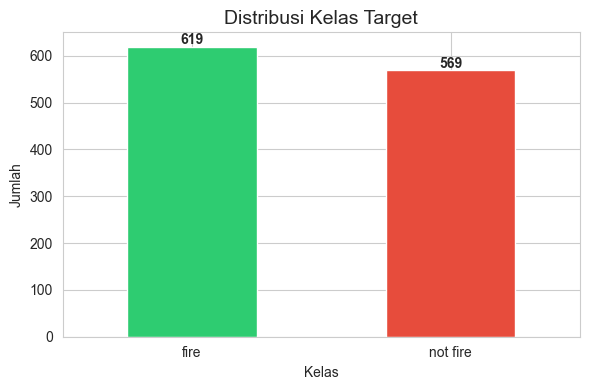

Proporsi: {'fire': np.float64(52.10437710437711), 'not fire': np.float64(47.8956228956229)}


In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = df['Classes'].value_counts()
class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Distribusi Kelas Target', fontsize=14)
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Proporsi: {dict(class_counts / len(df) * 100)}')

## 2. Distribusi Fitur Numerik (Histogram + KDE)

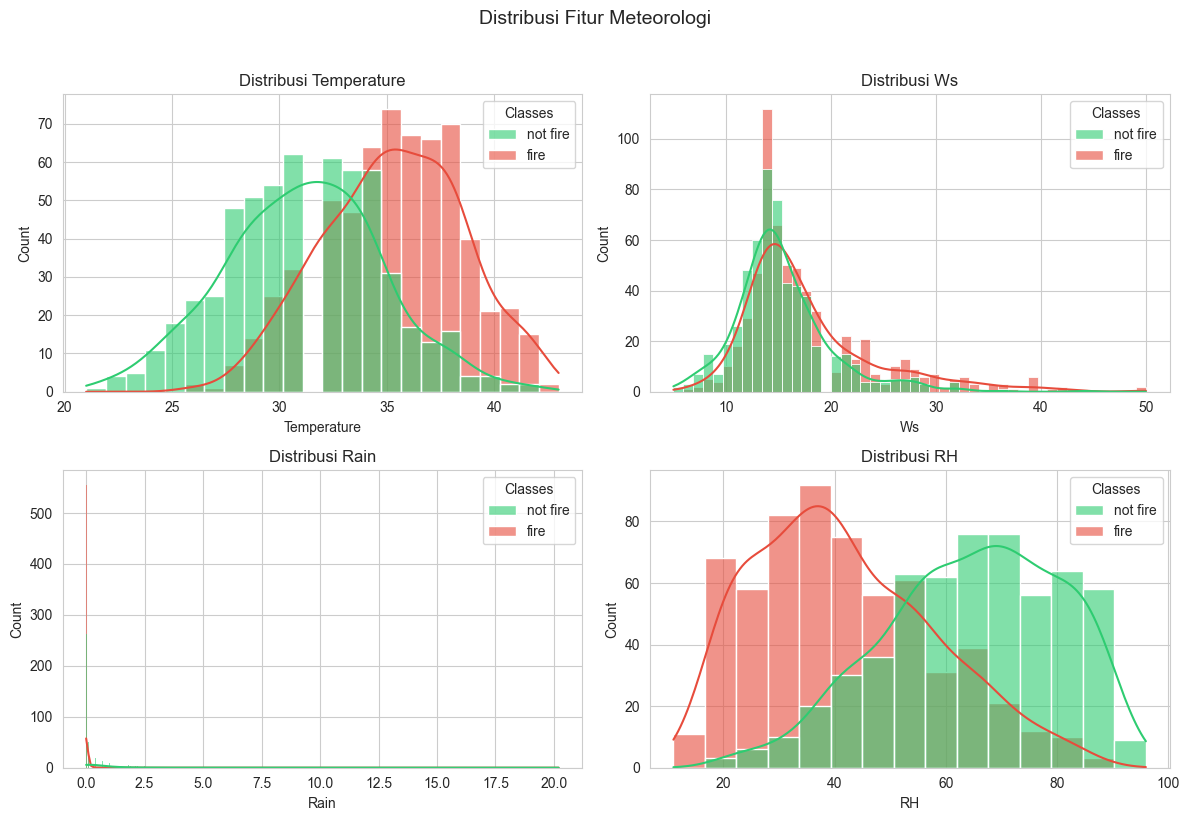

In [20]:
features_meteo = ['Temperature', 'Ws', 'Rain', 'RH']
features_fwi = ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_meteo):
    sns.histplot(data=df, x=col, hue='Classes', kde=True, ax=axes[i],
                 palette={'fire': '#e74c3c', 'not fire': '#2ecc71'}, alpha=0.6)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)

plt.suptitle('Distribusi Fitur Meteorologi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

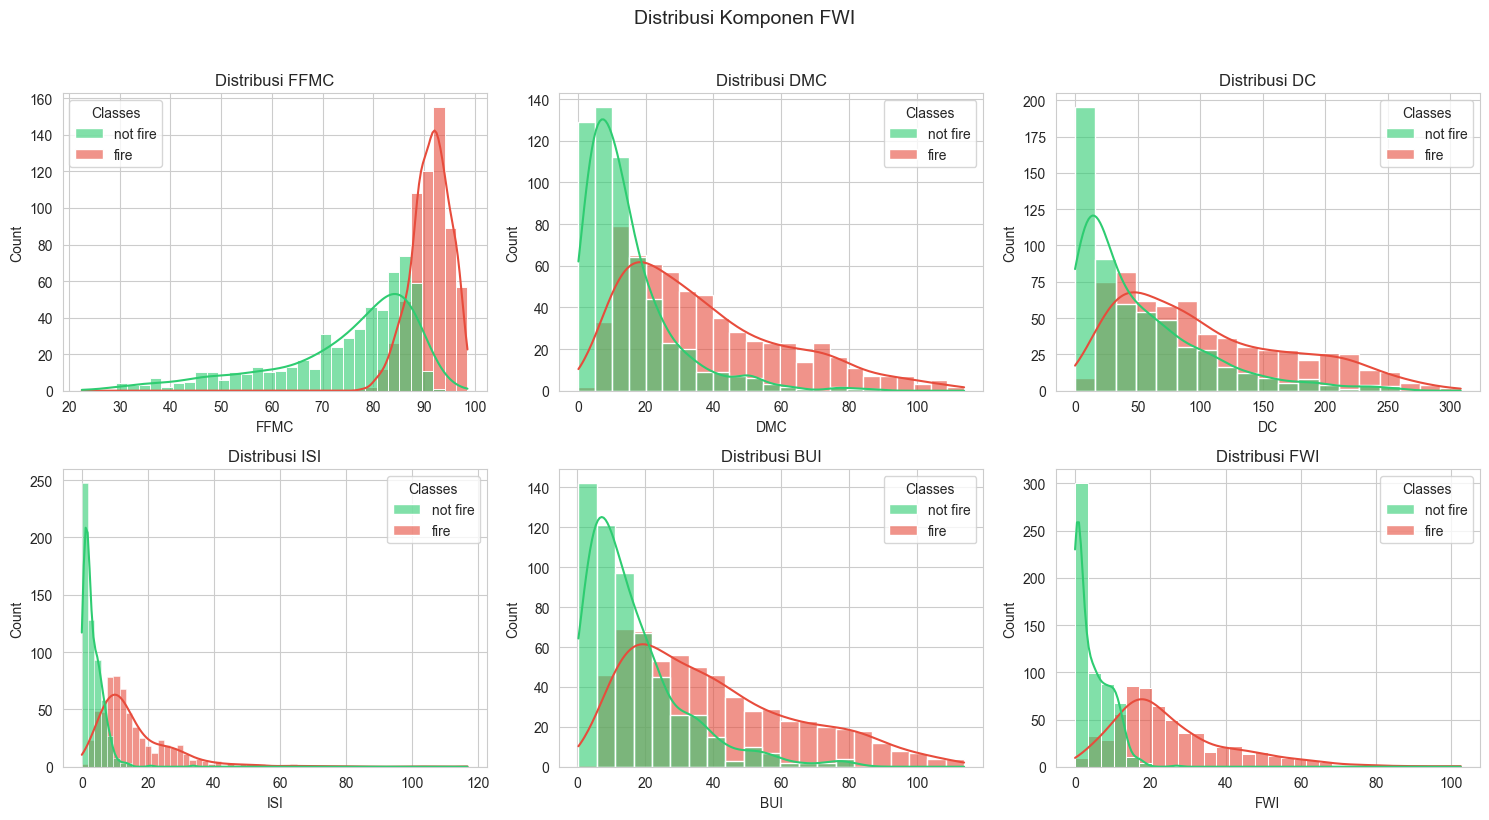

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_fwi):
    sns.histplot(data=df, x=col, hue='Classes', kde=True, ax=axes[i],
                 palette={'fire': '#e74c3c', 'not fire': '#2ecc71'}, alpha=0.6)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)

plt.suptitle('Distribusi Komponen FWI', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Boxplot per Fitur

C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],


C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],


C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],


C:\Users\ihram\AppData\Local\Temp\ipykernel_17800\3261132344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],


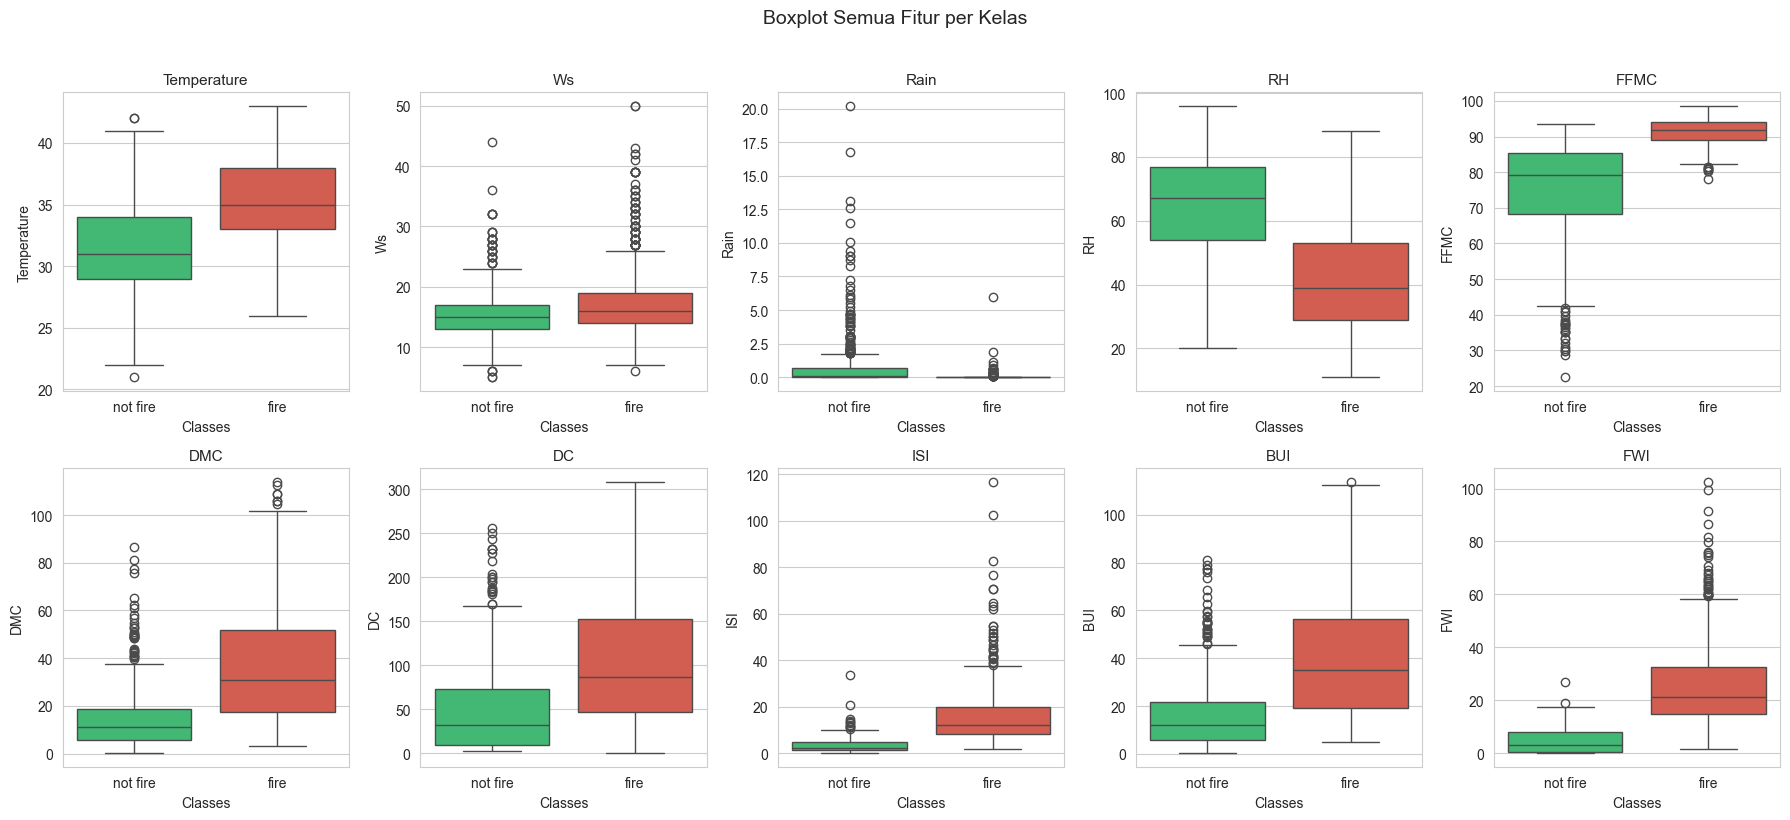

In [22]:
all_features = features_meteo + features_fwi

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(all_features):
    sns.boxplot(data=df, x='Classes', y=col, ax=axes[i],
                palette={'fire': '#e74c3c', 'not fire': '#2ecc71'})
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplot Semua Fitur per Kelas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Heatmap Korelasi

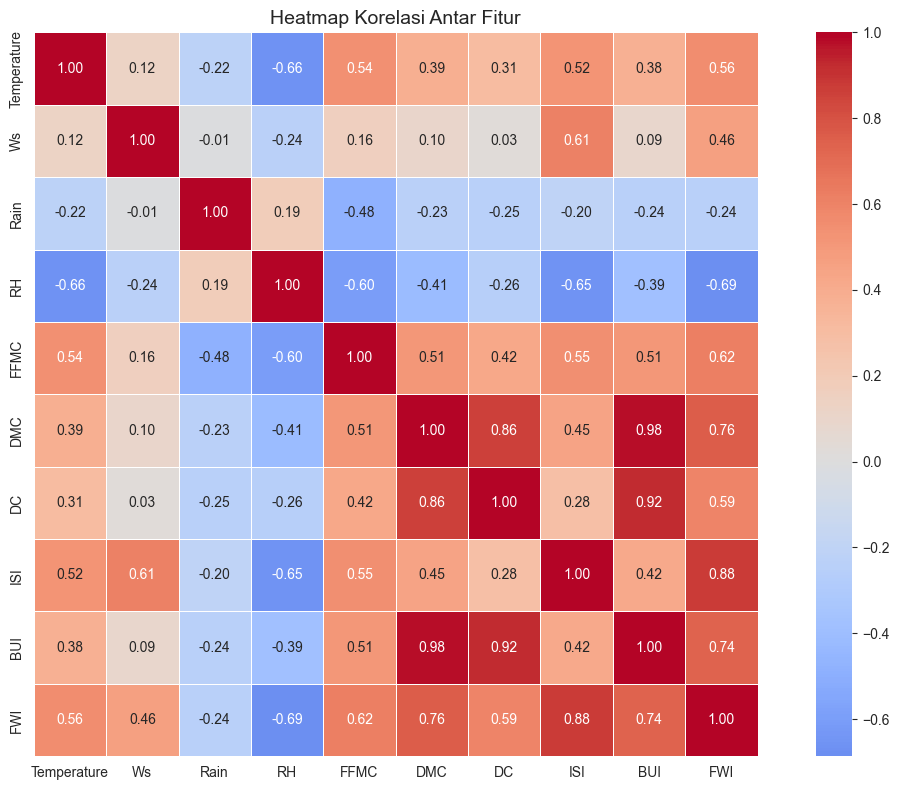

In [23]:
plt.figure(figsize=(12, 8))
corr = df[all_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Pairplot Fitur Kunci

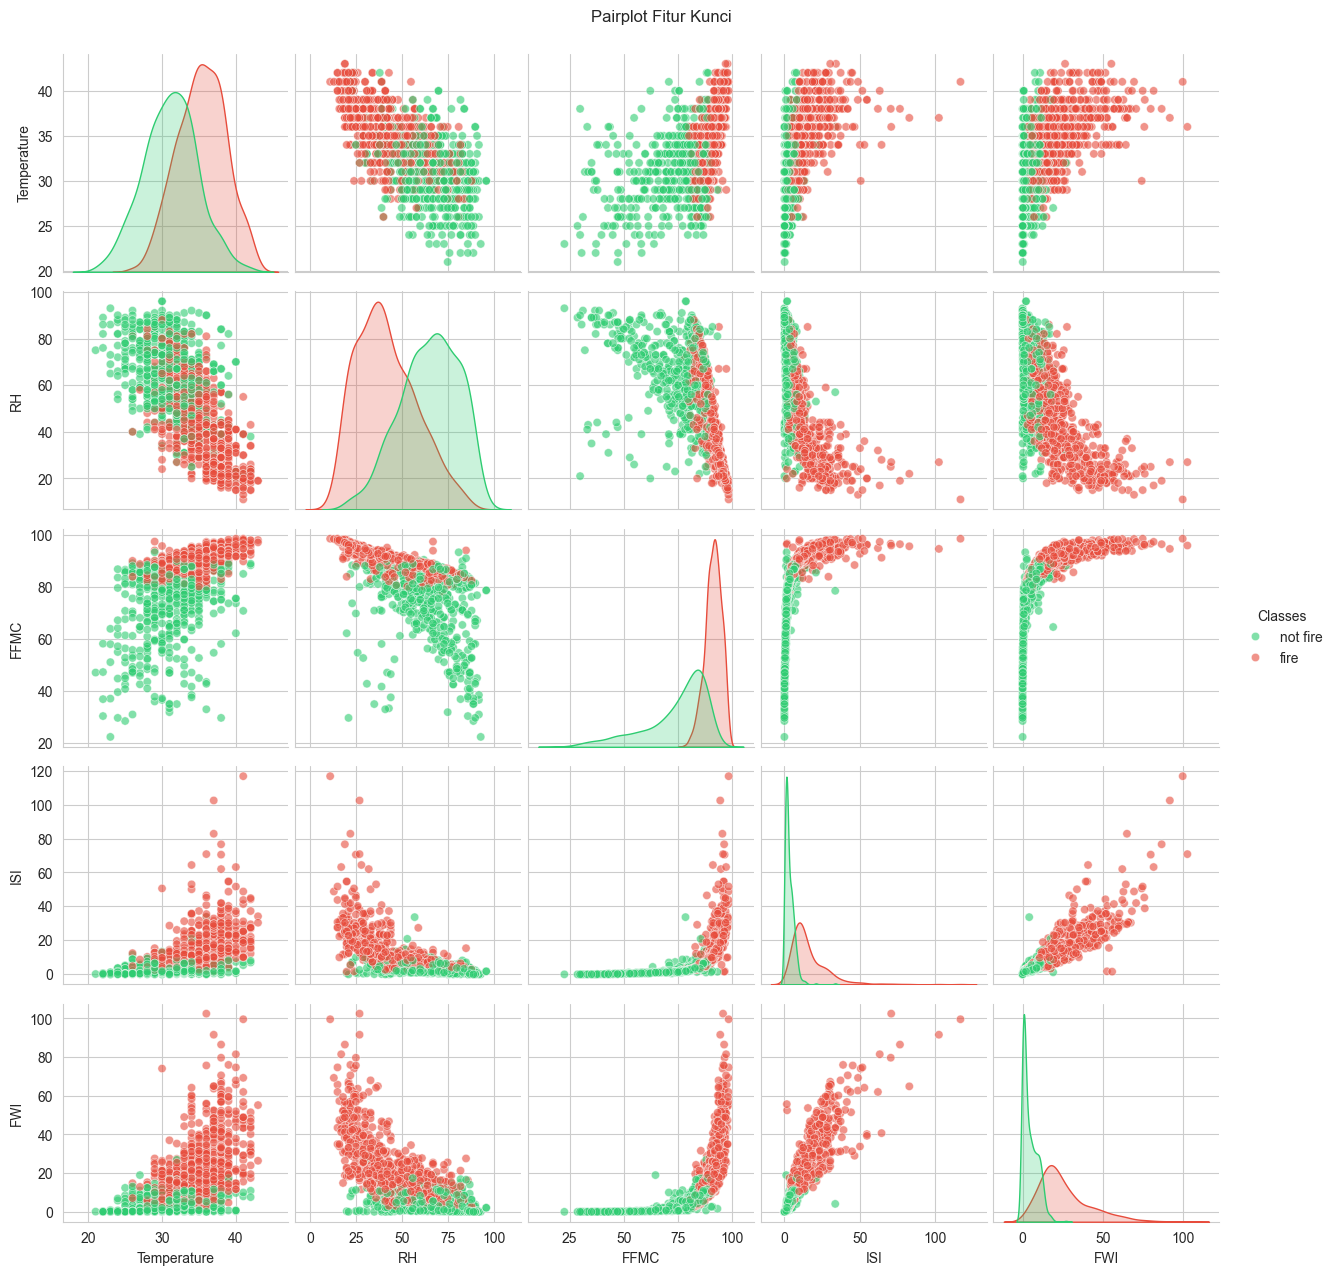

In [24]:
key_features = ['Temperature', 'RH', 'FFMC', 'ISI', 'FWI', 'Classes']
sns.pairplot(df[key_features], hue='Classes',
             palette={'fire': '#e74c3c', 'not fire': '#2ecc71'},
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Fitur Kunci', y=1.02)
plt.show()

## 6. Kesimpulan EDA Mendalam

### Temuan Utama

| No | Temuan | Implikasi |
|----|--------|----------|
| 1 | **Kelas seimbang** — fire (52.1%) vs not fire (47.9%), selisih hanya 4.2% | Tidak perlu teknik resampling (SMOTE/undersampling) |
| 2 | **Multicollinearity tinggi** — DMC-BUI (0.98), DC-BUI (0.92), ISI-FWI (0.88), DMC-DC (0.86) | Tree-based model robust terhadap multicollinearity, tidak perlu drop fitur |
| 3 | **Distribusi skewed** — Rain zero-inflated, ISI/DC/FWI right-skewed, FFMC left-skewed | Tidak perlu transformasi karena tree-based model tidak asumsikan normalitas |
| 4 | **Outlier** — Rain (hingga 20mm), ISI (>100), FWI (>100) | Tree-based model robust terhadap outlier, tidak perlu hapus/cap |
| 5 | **FFMC sebagai threshold kuat** — pola "L" pada pairplot, fire terkonsentrasi saat FFMC > 80 | Fitur ini sangat diskriminatif untuk klasifikasi |
| 6 | **Ws & Rain korelasi rendah** — korelasi linier rendah dengan fitur lain | Tetap dipertahankan karena tree-based model dapat menangkap non-linear pattern |

### Keputusan Teknis

| Keputusan | Pilihan | Alasan |
|-----------|---------|--------|
| Multicollinearity | Pertahankan semua fitur | Tree-based model tidak terpengaruh |
| Transformasi distribusi | Tidak dilakukan | Tree-based model tidak asumsikan normalitas |
| Outlier | Pertahankan semua | Tree-based model robust terhadap outlier |
| Fitur `Ws` & `Rain` | Pertahankan | Dapat menangkap pola non-linear |
| Rasio split | 80:20 | Dataset moderat (1.215), cukup untuk training & evaluasi |
| Model | Decision Tree, Random Forest, Gradient Boosting | Sesuai untuk data dengan multicolineritas & non-linear |

### Insight Pairplot
- **FFMC** menjadi pemisah utama: hampir semua kasus fire terjadi saat FFMC > 80
- **ISI-FWI** membentuk pola linear kuat pada data fire — keduanya saling berkorelasi 0.88
- **Temperature-RH** menunjukkan area tumpang tindih di 30–35°C dan RH 50–70% — perlu fitur lain untuk memisahkan

# Feature Engineering & Preprocessing

Tahap ini mempersiapkan data agar siap dimasukkan ke dalam model machine learning. Karena kita menggunakan **tree-based model**, preprocessing lebih sederhana — tidak diperlukan scaling atau transformasi.

## 1. Encoding Target Variabel

In [25]:
print('=== UNIQUE VALUES SEBELUM ENCODING ===')
print(df['Classes'].unique())

# Encoding: fire = 1, not fire = 0
df['Classes'] = df['Classes'].map({'fire': 1, 'not fire': 0})

print('\n=== UNIQUE VALUES SESUDAH ENCODING ===')
print(df['Classes'].unique())
print(f'Tipe data: {df["Classes"].dtype}')

print('\n=== DISTRIBUSI SETELAH ENCODING ===')
print(df['Classes'].value_counts())

=== UNIQUE VALUES SEBELUM ENCODING ===
['not fire' 'fire']

=== UNIQUE VALUES SESUDAH ENCODING ===
[0 1]
Tipe data: int64

=== DISTRIBUSI SETELAH ENCODING ===
Classes
1    619
0    569
Name: count, dtype: int64


## 2. Pemisahan Fitur (X) dan Target (y)

Hanya menggunakan **4 fitur meteorologi dasar**: Temperature, Ws, Rain, RH.

Fitur FWI (FFMC, DMC, DC, ISI, BUI, FWI) **tidak digunakan** karena merupakan indeks yang memang dirancang untuk memprediksi bahaya kebakaran — menggunakannya akan bersifat circular reasoning.

In [26]:
# Hanya gunakan 4 fitur meteorologi dasar
meteo_features = ['Temperature', 'Ws', 'Rain', 'RH']
X = df[meteo_features]
y = df['Classes']

print('=== FITUR (X) ===')
print(f'Jumlah fitur: {X.shape[1]}')
print(f'Kolom: {list(X.columns)}')
print(f'\nCatatan: Fitur FWI (FFMC, DMC, DC, ISI, BUI, FWI) TIDAK digunakan.')
print('Alasan: FWI adalah indeks yang dirancang untuk prediksi kebakaran.')

print('\n=== TARGET (y) ===')
print(f'Jumlah sampel: {len(y)}')
print(f'Distribusi:\n{y.value_counts()}')

=== FITUR (X) ===
Jumlah fitur: 4
Kolom: ['Temperature', 'Ws', 'Rain', 'RH']

Catatan: Fitur FWI (FFMC, DMC, DC, ISI, BUI, FWI) TIDAK digunakan.
Alasan: FWI adalah indeks yang dirancang untuk prediksi kebakaran.

=== TARGET (y) ===
Jumlah sampel: 1188
Distribusi:
Classes
1    619
0    569
Name: count, dtype: int64


# Pemodelan Baseline

Tahap ini bertujuan untuk membangun model baseline dengan 3 algoritma klasifikasi:
1. **Decision Tree** — model paling sederhana, rentan overfitting
2. **Random Forest** — ensemble dari Decision Tree, lebih robust
3. **XGBoost** — boosting algorithm, biasanya performa terbaik

Setiap model akan diuji dengan **3 variasi train-test split** (70:30, 80:20, 90:10) untuk melihat pengaruh proporsi data terhadap performa model.

Metrik evaluasi: Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix. Semua metrik dihitung untuk **train set** dan **test set** guna mendeteksi overfitting/underfitting.

## 1. Import Library

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 2. Definisi 3 Variasi Train-Test Split

| Split | Rasio | Train | Test | Keterangan |
|-------|-------|-------|------|------------|
| Split 1 | 70:30 | ~850 | ~365 | Test set besar, evaluasi stabil |
| Split 2 | 80:20 | ~972 | ~243 | Rasio standar |
| Split 3 | 90:10 | ~1093 | ~122 | Test set kecil, model belajar lebih banyak |

In [28]:
splits = {}
split_configs = [(0.30, '70:30'), (0.20, '80:20'), (0.10, '90:10')]

for test_size, name in split_configs:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    splits[name] = (X_tr, X_te, y_tr, y_te)
    print(f'Split {name}: Train={len(X_tr)} sampel, Test={len(X_te)} sampel')

print(f'\nTotal kombinasi yang akan diuji: {len(splits)} split x 3 model = {len(splits)*3} model')

Split 70:30: Train=831 sampel, Test=357 sampel
Split 80:20: Train=950 sampel, Test=238 sampel
Split 90:10: Train=1069 sampel, Test=119 sampel

Total kombinasi yang akan diuji: 3 split x 3 model = 9 model


## 3. Definisi 3 Model

Semua model menggunakan **regularisasi** untuk mencegah overfitting:

| Model | Parameter Utama |
|-------|------------------|
| Decision Tree | `max_depth=5, min_samples_leaf=10` |
| Random Forest | `n_estimators=100, max_depth=10, min_samples_leaf=5` |
| XGBoost | `n_estimators=100, max_depth=4, min_child_weight=5` |

In [29]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=4,
        min_child_weight=5,
        random_state=42,
        eval_metric='logloss'
    )
}

print('Model dengan regularisasi:')
for name, model in models.items():
    print(f'  - {name}: {model.__class__.__name__}')
    print(f'    Params: {model.get_params()}')

Model dengan regularisasi:
  - Decision Tree: DecisionTreeClassifier
    Params: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
  - Random Forest: RandomForestClassifier
    Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
  - XGBoost: XGBClassifier
    Params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 

## 4. Training & Evaluasi (Loop)

Setiap kombinasi (split x model) akan:
1. Clone model agar fresh setiap iterasi
2. Training pada train set
3. Prediksi di **train set** dan **test set**
4. Hitung 5 metrik untuk train dan test
5. Hitung gap (train - test) untuk diagnosa overfitting
6. Simpan confusion matrix

In [30]:
results = []

for split_name, (X_tr, X_te, y_tr, y_te) in splits.items():
    print(f'\n{"="*60}')
    print(f'SPLIT: {split_name}')
    print(f'{"="*60}')
    
    for model_name, model_template in models.items():
        print(f'\n--- {model_name} ---')
        
        # Clone model agar fresh setiap iterasi
        model = clone(model_template)
        
        # Training
        model.fit(X_tr, y_tr)
        
        # Prediksi TRAIN
        y_train_pred = model.predict(X_tr)
        y_train_proba = model.predict_proba(X_tr)[:, 1]
        
        # Prediksi TEST
        y_test_pred = model.predict(X_te)
        y_test_proba = model.predict_proba(X_te)[:, 1]
        
        # Hitung metrik TRAIN
        train_acc = accuracy_score(y_tr, y_train_pred)
        train_prec = precision_score(y_tr, y_train_pred)
        train_rec = recall_score(y_tr, y_train_pred)
        train_f1 = f1_score(y_tr, y_train_pred)
        train_auc = roc_auc_score(y_tr, y_train_proba)
        
        # Hitung metrik TEST
        test_acc = accuracy_score(y_te, y_test_pred)
        test_prec = precision_score(y_te, y_test_pred)
        test_rec = recall_score(y_te, y_test_pred)
        test_f1 = f1_score(y_te, y_test_pred)
        test_auc = roc_auc_score(y_te, y_test_proba)
        
        # Hitung GAP
        gap_acc = train_acc - test_acc
        gap_f1 = train_f1 - test_f1
        
        # Simpan hasil
        results.append({
            'Model': model_name,
            'Split': split_name,
            'Train Acc': train_acc,
            'Test Acc': test_acc,
            'Gap Acc': gap_acc,
            'Train F1': train_f1,
            'Test F1': test_f1,
            'Gap F1': gap_f1,
            'Train Prec': train_prec,
            'Test Prec': test_prec,
            'Train Rec': train_rec,
            'Test Rec': test_rec,
            'Train AUC': train_auc,
            'Test AUC': test_auc,
            'y_test_true': y_te,
            'y_test_pred': y_test_pred
        })
        
        # Print hasil
        print(f'  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {gap_acc:.4f}')
        print(f'  Train F1:  {train_f1:.4f} | Test F1:  {test_f1:.4f} | Gap: {gap_f1:.4f}')

print(f'\n\nTraining selesai! Total {len(results)} kombinasi model telah dievaluasi.')


SPLIT: 70:30

--- Decision Tree ---
  Train Acc: 0.8508 | Test Acc: 0.8347 | Gap: 0.0160
  Train F1:  0.8591 | Test F1:  0.8451 | Gap: 0.0139

--- Random Forest ---


  Train Acc: 0.8833 | Test Acc: 0.8515 | Gap: 0.0317
  Train F1:  0.8881 | Test F1:  0.8564 | Gap: 0.0318

--- XGBoost ---


  Train Acc: 0.9001 | Test Acc: 0.8543 | Gap: 0.0458
  Train F1:  0.9047 | Test F1:  0.8610 | Gap: 0.0437

SPLIT: 80:20

--- Decision Tree ---
  Train Acc: 0.8526 | Test Acc: 0.8193 | Gap: 0.0333
  Train F1:  0.8548 | Test F1:  0.8139 | Gap: 0.0409

--- Random Forest ---


  Train Acc: 0.8842 | Test Acc: 0.8487 | Gap: 0.0355
  Train F1:  0.8891 | Test F1:  0.8512 | Gap: 0.0379

--- XGBoost ---
  Train Acc: 0.8979 | Test Acc: 0.8403 | Gap: 0.0576
  Train F1:  0.9027 | Test F1:  0.8430 | Gap: 0.0597

SPLIT: 90:10

--- Decision Tree ---
  Train Acc: 0.8447 | Test Acc: 0.8235 | Gap: 0.0212
  Train F1:  0.8523 | Test F1:  0.8235 | Gap: 0.0288

--- Random Forest ---


  Train Acc: 0.8859 | Test Acc: 0.8655 | Gap: 0.0203
  Train F1:  0.8911 | Test F1:  0.8644 | Gap: 0.0267

--- XGBoost ---
  Train Acc: 0.8971 | Test Acc: 0.8655 | Gap: 0.0316
  Train F1:  0.9028 | Test F1:  0.8667 | Gap: 0.0362


Training selesai! Total 9 kombinasi model telah dievaluasi.


## 5. Tabel Perbandingan Hasil

Tabel berikut menampilkan perbandingan metrik **train** dan **test** untuk semua kombinasi model dan split. Kolom **Gap** menunjukkan selisih antara train dan test — gap yang besar menandakan potensi overfitting.

In [31]:
df_results = pd.DataFrame(results)

display_cols = [
    'Model', 'Split',
    'Train Acc', 'Test Acc', 'Gap Acc',
    'Train F1', 'Test F1', 'Gap F1',
    'Train Prec', 'Test Prec',
    'Train Rec', 'Test Rec',
    'Train AUC', 'Test AUC'
]

print('=== TABEL PERBANDINGAN HASIL (SEMUA METRIK) ===')
print()
print(df_results[display_cols].to_string(index=False))

=== TABEL PERBANDINGAN HASIL (SEMUA METRIK) ===

        Model Split  Train Acc  Test Acc  Gap Acc  Train F1  Test F1   Gap F1  Train Prec  Test Prec  Train Rec  Test Rec  Train AUC  Test AUC
Decision Tree 70:30   0.850782  0.834734 0.016048  0.859091 0.845144 0.013947    0.845638   0.825641   0.872979  0.865591   0.922995  0.902188
Random Forest 70:30   0.883273  0.851541 0.031733  0.888120 0.856369 0.031751    0.887097   0.863388   0.889145  0.849462   0.958598  0.925659
      XGBoost 70:30   0.900120  0.854342 0.045779  0.904707 0.860963 0.043745    0.899543   0.856383   0.909931  0.865591   0.963414  0.913082
Decision Tree 80:20   0.852632  0.819328 0.033304  0.854772 0.813853 0.040919    0.878465   0.878505   0.832323  0.758065   0.929779  0.889997
Random Forest 80:20   0.884211  0.848739 0.035471  0.889113 0.851240 0.037873    0.887324   0.872881   0.890909  0.830645   0.959445  0.925085
      XGBoost 80:20   0.897895  0.840336 0.057559  0.902708 0.842975 0.059733    0.896414   0

## 6. Diagnosa Overfitting / Underfitting

Diagnosa berdasarkan **Gap Accuracy** (Train Acc - Test Acc):

| Kondisi | Threshold | Keterangan |
|---------|-----------|------------|
| **Good Fit** | Gap < 5% | Model generalizes dengan baik |
| **Mild Overfitting** | Gap 5-15% | Sedikit overfitting, masih bisa diterima |
| **Severe Overfitting** | Gap > 15% | Overfitting parah, perlu perbaikan |
| **Underfitting** | Test Acc < 70% | Model terlalu sederhana |

In [32]:
def diagnose(gap_acc, test_acc):
    if test_acc < 0.70:
        return 'Underfitting'
    elif gap_acc > 0.15:
        return 'Severe Overfitting'
    elif gap_acc > 0.05:
        return 'Mild Overfitting'
    else:
        return 'Good Fit'

df_results['Status'] = df_results.apply(
    lambda r: diagnose(r['Gap Acc'], r['Test Acc']), axis=1
)

print('=== DIAGNOSA OVERFITTING / UNDERFITTING ===')
print()
diag_cols = ['Model', 'Split', 'Train Acc', 'Test Acc', 'Gap Acc', 'Status']
print(df_results[diag_cols].to_string(index=False))

=== DIAGNOSA OVERFITTING / UNDERFITTING ===

        Model Split  Train Acc  Test Acc  Gap Acc           Status
Decision Tree 70:30   0.850782  0.834734 0.016048         Good Fit
Random Forest 70:30   0.883273  0.851541 0.031733         Good Fit
      XGBoost 70:30   0.900120  0.854342 0.045779         Good Fit
Decision Tree 80:20   0.852632  0.819328 0.033304         Good Fit
Random Forest 80:20   0.884211  0.848739 0.035471         Good Fit
      XGBoost 80:20   0.897895  0.840336 0.057559 Mild Overfitting
Decision Tree 90:10   0.844715  0.823529 0.021185         Good Fit
Random Forest 90:10   0.885875  0.865546 0.020328         Good Fit
      XGBoost 90:10   0.897100  0.865546 0.031554         Good Fit


## 7. Identifikasi Model Terbaik

Model terbaik dipilih berdasarkan **F1-Score pada test set** tertinggi. F1-Score dipilih karena memberikan keseimbangan antara precision dan recall, yang penting untuk dataset dengan distribusi kelas yang tidak perfectly balanced.

In [33]:
# Cari model dengan Test F1 tertinggi
best_idx = df_results['Test F1'].idxmax()
best_row = df_results.loc[best_idx]
best_model_name = best_row['Model']
best_split = best_row['Split']

print('='*60)
print('MODEL TERBAIK')
print('='*60)
print(f'Model        : {best_model_name}')
print(f'Split        : {best_split}')
print(f'Test F1      : {best_row["Test F1"]:.4f}')
print(f'Test Acc     : {best_row["Test Acc"]:.4f}')
print(f'Test AUC     : {best_row["Test AUC"]:.4f}')
print(f'Test Prec    : {best_row["Test Prec"]:.4f}')
print(f'Test Rec     : {best_row["Test Rec"]:.4f}')
print(f'Gap Acc      : {best_row["Gap Acc"]:.4f}')
print(f'Status       : {best_row["Status"]}')

MODEL TERBAIK
Model        : XGBoost
Split        : 90:10
Test F1      : 0.8667
Test Acc     : 0.8655
Test AUC     : 0.9219
Test Prec    : 0.8966
Test Rec     : 0.8387
Gap Acc      : 0.0316
Status       : Good Fit


## 8. Confusion Matrix — Model Terbaik

Confusion matrix ditampilkan untuk model terbaik pada ketiga variasi split. Hal ini memungkinkan kita melihat bagaimana model mengklasifikasikan data di setiap split.

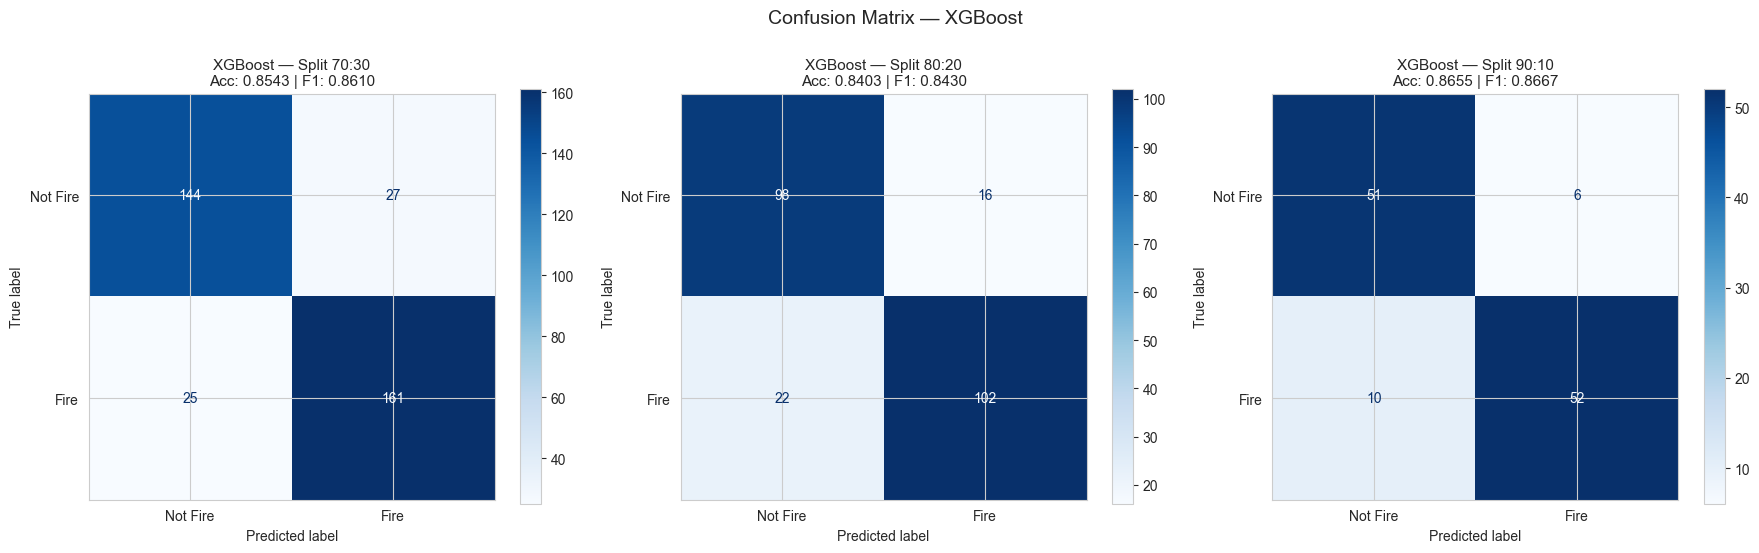

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split_name in enumerate(['70:30', '80:20', '90:10']):
    row = df_results[(df_results['Model'] == best_model_name) & (df_results['Split'] == split_name)].iloc[0]
    
    cm = confusion_matrix(row['y_test_true'], row['y_test_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Fire', 'Fire'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(
        f'{best_model_name} — Split {split_name}\n'
        f'Acc: {row["Test Acc"]:.4f} | F1: {row["Test F1"]:.4f}',
        fontsize=11
    )

plt.suptitle(f'Confusion Matrix — {best_model_name}', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 9. Cross-Validation (5-Fold Stratified)

Cross-validation memberikan estimasi performa yang lebih robust daripada single train-test split. Dengan **Stratified K-Fold**, proporsi kelas tetap terjaga di setiap fold.

Dilakukan pada model terbaik dengan seluruh data (X, y).

In [35]:
print(f'=== CROSS-VALIDATION (5-Fold Stratified) — {best_model_name} ===')
print()

# Clone model terbaik
best_model_cv = clone(models[best_model_name])

# Definisi scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation untuk setiap metrik
cv_results = {}
for metric_name, metric_scorer in scoring.items():
    scores = cross_val_score(best_model_cv, X, y, cv=skf, scoring=metric_scorer)
    cv_results[metric_name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f'  {metric_name:>12}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print(f'              Fold scores: {[f"{s:.4f}" for s in scores]}')

=== CROSS-VALIDATION (5-Fold Stratified) — XGBoost ===



      accuracy: 0.8266 (+/- 0.0307)
              Fold scores: ['0.8529', '0.7941', '0.8655', '0.8312', '0.7890']


     precision: 0.8243 (+/- 0.0283)
              Fold scores: ['0.8560', '0.8049', '0.8594', '0.8120', '0.7891']


        recall: 0.8482 (+/- 0.0353)
              Fold scores: ['0.8629', '0.7984', '0.8871', '0.8780', '0.8145']


            f1: 0.8359 (+/- 0.0295)
              Fold scores: ['0.8594', '0.8016', '0.8730', '0.8438', '0.8016']


       roc_auc: 0.9041 (+/- 0.0289)
              Fold scores: ['0.9255', '0.8692', '0.9379', '0.9180', '0.8700']


In [36]:
# Tabel ringkasan CV
print('\n=== RINGKASAN CROSS-VALIDATION ===')
cv_df = pd.DataFrame({
    'Metric': list(cv_results.keys()),
    'Mean': [v['mean'] for v in cv_results.values()],
    'Std': [v['std'] for v in cv_results.values()]
})
cv_df['Mean (%)'] = (cv_df['Mean'] * 100).round(2)
cv_df['Std (%)'] = (cv_df['Std'] * 100).round(2)
print(cv_df[['Metric', 'Mean (%)', 'Std (%)']].to_string(index=False))


=== RINGKASAN CROSS-VALIDATION ===
   Metric  Mean (%)  Std (%)
 accuracy     82.66     3.07
precision     82.43     2.83
   recall     84.82     3.53
       f1     83.59     2.95
  roc_auc     90.41     2.89


## 10. Kesimpulan Pemodelan Baseline

### Konfigurasi Eksperimen
- **Fitur**: 4 fitur meteorologi dasar (Temperature, Ws, Rain, RH)
- **Fitur FWI dikecualikan** karena bersifat circular reasoning
- **Regularisasi** diterapkan pada semua model untuk mencegah overfitting
- **Duplikat silang-region** telah dihapus sebelum split

### Ringkasan Hasil

1. **XGBoost 90:10 menjadi model terbaik** — Test F1 **0.8667**, Test Acc **0.8655**, Test AUC **0.9219**, gap accuracy **3.16%** (Good Fit).
2. **XGBoost unggul pada split 70:30 dan 90:10**; pada 80:20 posisinya digantikan Random Forest karena XGBoost mengalami *Mild Overfitting* (gap accuracy 5.76%).
3. **Random Forest menjadi pesaing terdekat** dengan gap kecil di hampir semua split.
4. **8 dari 9 kombinasi berstatus Good Fit** (gap accuracy < 5%); satu-satunya pengecualian adalah XGBoost 80:20.
5. **Decision Tree paling rendah** di semua split — kurang mampu menangkap pola non-linear dari 4 fitur meteo.

### Model Terbaik
- **Model**: XGBoost
- **Split**: 90:10
- **Test F1-Score**: 0.8667
- **Test Accuracy**: 0.8655
- **Test AUC**: 0.9219
- **Status**: Good Fit (gap accuracy 3.16%)

### Observasi Penting
1. **Pengaruh Regularisasi**: regularisasi menjaga gap train-test tetap kecil (mayoritas < 5%); XGBoost 80:20 tetap menunjukkan gap 5.76%, namun mengecil ke 3.16% ketika data training diperbesar menjadi 90%.
2. **Pengaruh Fitur**: dengan hanya 4 fitur meteorologi dasar (Temperature, Ws, Rain, RH), XGBoost tetap mencapai Test F1 0.8667 dan AUC 0.9219 — indeks FWI (yang bersifat circular) tidak diperlukan untuk deteksi yang baik.
3. **Pengaruh Deduplikasi**: 27 baris duplikat silang-region dihapus (1.215 → 1.188, −2.2%), mencegah data leakage saat split; komposisi kelas tetap seimbang (fire 619 / not fire 569).

### Langkah Selanjutnya
- **Hyperparameter Tuning** — optimasi parameter model terbaik
- **Feature Engineering** — eksperimen fitur baru dari data meteo
- **Threshold Tuning** — optimasi threshold klasifikasi

# Hyperparameter Tuning

Setelah mendapatkan baseline model, langkah selanjutnya adalah **mengoptimasi hyperparameter** model terbaik menggunakan **RandomizedSearchCV**.

**Mengapa RandomizedSearchCV?**
- Lebih cepat dari GridSearchCV (tidak mencoba semua kombinasi)
- Cukup efektif untuk menemukan parameter yang mendekati optimal
- 100 iterasi dengan 5-fold CV memberikan estimasi yang cukup robust

**Objek tuning**: Model terbaik dari baseline pada split terbaik

## 1. Import Library Tuning

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print('Library tuning berhasil diimport!')

Library tuning berhasil diimport!


## 2. Identifikasi Model & Split Terbaik dari Baseline

Model dan split yang akan dituning dipilih berdasarkan **F1-Score tertinggi pada test set** dari hasil baseline.

In [38]:
# Ambil model terbaik dari hasil baseline
best_idx = df_results['Test F1'].idxmax()
best_row = df_results.loc[best_idx]
best_model_name = best_row['Model']
best_split = best_row['Split']

# Ambil data split terbaik
X_tr_best, X_te_best, y_tr_best, y_te_best = splits[best_split]

print('='*60)
print('MODEL & SPLIT TERBAIK DARI BASELINE')
print('='*60)
print(f'Model         : {best_model_name}')
print(f'Split         : {best_split}')
print(f'Train samples : {len(X_tr_best)}')
print(f'Test samples  : {len(X_te_best)}')
print()
print('Baseline Metrics:')
print(f'  Train Acc   : {best_row["Train Acc"]:.4f}')
print(f'  Test Acc    : {best_row["Test Acc"]:.4f}')
print(f'  Gap Acc     : {best_row["Gap Acc"]:.4f}')
print(f'  Train F1    : {best_row["Train F1"]:.4f}')
print(f'  Test F1     : {best_row["Test F1"]:.4f}')
print(f'  Gap F1      : {best_row["Gap F1"]:.4f}')
print(f'  Test AUC    : {best_row["Test AUC"]:.4f}')
print(f'  Status      : {best_row["Status"]}')

MODEL & SPLIT TERBAIK DARI BASELINE
Model         : XGBoost
Split         : 90:10
Train samples : 1069
Test samples  : 119

Baseline Metrics:
  Train Acc   : 0.8971
  Test Acc    : 0.8655
  Gap Acc     : 0.0316
  Train F1    : 0.9028
  Test F1     : 0.8667
  Gap F1      : 0.0362
  Test AUC    : 0.9219
  Status      : Good Fit


## 3. Definisi Parameter Grid

Parameter grid ditentukan berdasarkan **best practice** masing-masing model. RandomizedSearchCV akan memilih secara acak dari distribusi parameter yang didefinisikan.

In [39]:
# Definisi parameter grid berdasarkan model terbaik
if best_model_name == 'Decision Tree':
    param_dist = {
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 15, 20],
        'min_samples_leaf': [1, 2, 5, 10, 15, 20],
        'criterion': ['gini', 'entropy'],
        'max_features': ['sqrt', 'log2', None]
    }
    base_model = DecisionTreeClassifier(random_state=42)

elif best_model_name == 'Random Forest':
    param_dist = {
        'n_estimators': [50, 100, 150, 200, 300],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'XGBoost':
    param_dist = {
        'n_estimators': [50, 100, 150, 200, 300],
        'max_depth': [3, 4, 5, 6, 7, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'min_child_weight': [1, 3, 5, 7, 9],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2, 0.3],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [0, 0.01, 0.1, 1]
    }
    base_model = XGBClassifier(random_state=42, eval_metric='logloss')

print(f'Parameter grid untuk {best_model_name}:')
print(f'Jumlah kombinasi parameter: {sum(len(v) if isinstance(v, list) else 1 for v in param_dist.values())}+')
print()
for param, values in param_dist.items():
    print(f'  {param}: {values}')

Parameter grid untuk XGBoost:
Jumlah kombinasi parameter: 41+

  n_estimators: [50, 100, 150, 200, 300]
  max_depth: [3, 4, 5, 6, 7, 8]
  learning_rate: [0.01, 0.05, 0.1, 0.15, 0.2]
  min_child_weight: [1, 3, 5, 7, 9]
  subsample: [0.7, 0.8, 0.9, 1.0]
  colsample_bytree: [0.7, 0.8, 0.9, 1.0]
  gamma: [0, 0.1, 0.2, 0.3]
  reg_alpha: [0, 0.01, 0.1, 1]
  reg_lambda: [0, 0.01, 0.1, 1]


## 4. Eksekusi RandomizedSearchCV

- **100 iterasi** parameter combination
- **5-Fold Stratified CV**
- **Scoring**: F1 (primary)
- **random_state=42** untuk reproducibility

In [40]:
print('Menjalankan RandomizedSearchCV...')
print(f'Model: {best_model_name}')
print(f'Iterasi: 100')
print(f'CV: 5-Fold Stratified')
print(f'Scoring: F1')
print()

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Fit pada seluruh data (X, y) karena CV sudah handle split
random_search.fit(X, y)

print('RandomizedSearchCV selesai!')
print()
print(f'Best CV F1 Score: {random_search.best_score_:.4f}')
print(f'Best Parameters:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')

Menjalankan RandomizedSearchCV...
Model: XGBoost
Iterasi: 100
CV: 5-Fold Stratified
Scoring: F1



RandomizedSearchCV selesai!

Best CV F1 Score: 0.8576
Best Parameters:
  subsample: 0.7
  reg_lambda: 1
  reg_alpha: 1
  n_estimators: 150
  min_child_weight: 9
  max_depth: 5
  learning_rate: 0.05
  gamma: 0.2
  colsample_bytree: 0.7


## 5. Hasil Tuning

Parameter terbaik dari hasil RandomizedSearchCV akan digunakan untuk membuat model tuned. Model ini kemudian dievaluasi pada split yang sama dengan baseline (train-test split).

In [41]:
# Buat model dengan parameter terbaik
tuned_model = random_search.best_estimator_

# Training pada split terbaik
tuned_model.fit(X_tr_best, y_tr_best)

# Prediksi TRAIN
y_train_pred_tuned = tuned_model.predict(X_tr_best)
y_train_proba_tuned = tuned_model.predict_proba(X_tr_best)[:, 1]

# Prediksi TEST
y_test_pred_tuned = tuned_model.predict(X_te_best)
y_test_proba_tuned = tuned_model.predict_proba(X_te_best)[:, 1]

# Hitung metrik TRAIN
tuned_train_acc = accuracy_score(y_tr_best, y_train_pred_tuned)
tuned_train_prec = precision_score(y_tr_best, y_train_pred_tuned)
tuned_train_rec = recall_score(y_tr_best, y_train_pred_tuned)
tuned_train_f1 = f1_score(y_tr_best, y_train_pred_tuned)
tuned_train_auc = roc_auc_score(y_tr_best, y_train_proba_tuned)

# Hitung metrik TEST
tuned_test_acc = accuracy_score(y_te_best, y_test_pred_tuned)
tuned_test_prec = precision_score(y_te_best, y_test_pred_tuned)
tuned_test_rec = recall_score(y_te_best, y_test_pred_tuned)
tuned_test_f1 = f1_score(y_te_best, y_test_pred_tuned)
tuned_test_auc = roc_auc_score(y_te_best, y_test_proba_tuned)

# Hitung GAP
tuned_gap_acc = tuned_train_acc - tuned_test_acc
tuned_gap_f1 = tuned_train_f1 - tuned_test_f1

print('Model Tuned - Evaluasi pada Split', best_split)
print('='*50)
print(f'Train Acc  : {tuned_train_acc:.4f}')
print(f'Test Acc   : {tuned_test_acc:.4f}')
print(f'Gap Acc    : {tuned_gap_acc:.4f}')
print()
print(f'Train F1   : {tuned_train_f1:.4f}')
print(f'Test F1    : {tuned_test_f1:.4f}')
print(f'Gap F1     : {tuned_gap_f1:.4f}')
print()
print(f'Test AUC   : {tuned_test_auc:.4f}')
print(f'Test Prec  : {tuned_test_prec:.4f}')
print(f'Test Rec   : {tuned_test_rec:.4f}')

Model Tuned - Evaluasi pada Split 90:10
Train Acc  : 0.8709
Test Acc   : 0.8487
Gap Acc    : 0.0222

Train F1   : 0.8763
Test F1    : 0.8475
Gap F1     : 0.0289

Test AUC   : 0.9403
Test Prec  : 0.8929
Test Rec   : 0.8065


## 6. Perbandingan Baseline vs Tuned

Tabel berikut membandingkan metrik baseline dengan tuned model pada split yang sama. **Delta** menunjukkan perubahan (positif = peningkatan, negatif = penurunan).

In [42]:
# Ambil baseline metrics
baseline_train_acc = best_row['Train Acc']
baseline_test_acc = best_row['Test Acc']
baseline_gap_acc = best_row['Gap Acc']
baseline_train_f1 = best_row['Train F1']
baseline_test_f1 = best_row['Test F1']
baseline_gap_f1 = best_row['Gap F1']
baseline_test_auc = best_row['Test AUC']
baseline_test_prec = best_row['Test Prec']
baseline_test_rec = best_row['Test Rec']

# Buat tabel perbandingan
comparison = pd.DataFrame({
    'Metric': [
        'Train Accuracy', 'Test Accuracy', 'Gap Accuracy',
        'Train F1', 'Test F1', 'Gap F1',
        'Test AUC', 'Test Precision', 'Test Recall'
    ],
    'Baseline': [
        f'{baseline_train_acc:.4f}', f'{baseline_test_acc:.4f}', f'{baseline_gap_acc:.4f}',
        f'{baseline_train_f1:.4f}', f'{baseline_test_f1:.4f}', f'{baseline_gap_f1:.4f}',
        f'{baseline_test_auc:.4f}', f'{baseline_test_prec:.4f}', f'{baseline_test_rec:.4f}'
    ],
    'Tuned': [
        f'{tuned_train_acc:.4f}', f'{tuned_test_acc:.4f}', f'{tuned_gap_acc:.4f}',
        f'{tuned_train_f1:.4f}', f'{tuned_test_f1:.4f}', f'{tuned_gap_f1:.4f}',
        f'{tuned_test_auc:.4f}', f'{tuned_test_prec:.4f}', f'{tuned_test_rec:.4f}'
    ],
    'Delta': [
        f'{tuned_train_acc - baseline_train_acc:+.4f}',
        f'{tuned_test_acc - baseline_test_acc:+.4f}',
        f'{tuned_gap_acc - baseline_gap_acc:+.4f}',
        f'{tuned_train_f1 - baseline_train_f1:+.4f}',
        f'{tuned_test_f1 - baseline_test_f1:+.4f}',
        f'{tuned_gap_f1 - baseline_gap_f1:+.4f}',
        f'{tuned_test_auc - baseline_test_auc:+.4f}',
        f'{tuned_test_prec - baseline_test_prec:+.4f}',
        f'{tuned_test_rec - baseline_test_rec:+.4f}'
    ]
})

print('='*60)
print(f'PERBANDINGAN: BASELINE vs TUNED ({best_model_name} — Split {best_split})')
print('='*60)
print()
print(comparison.to_string(index=False))
print()

# Ringkasan
f1_improvement = tuned_test_f1 - baseline_test_f1
acc_improvement = tuned_test_acc - baseline_test_acc
print(f'Ringkasan Perubahan:')
print(f'  F1-Score  : {baseline_test_f1:.4f} -> {tuned_test_f1:.4f} ({f1_improvement:+.4f})')
print(f'  Accuracy  : {baseline_test_acc:.4f} -> {tuned_test_acc:.4f} ({acc_improvement:+.4f})')

PERBANDINGAN: BASELINE vs TUNED (XGBoost — Split 90:10)

        Metric Baseline  Tuned   Delta
Train Accuracy   0.8971 0.8709 -0.0262
 Test Accuracy   0.8655 0.8487 -0.0168
  Gap Accuracy   0.0316 0.0222 -0.0094
      Train F1   0.9028 0.8763 -0.0265
       Test F1   0.8667 0.8475 -0.0192
        Gap F1   0.0362 0.0289 -0.0073
      Test AUC   0.9219 0.9403 +0.0184
Test Precision   0.8966 0.8929 -0.0037
   Test Recall   0.8387 0.8065 -0.0323

Ringkasan Perubahan:
  F1-Score  : 0.8667 -> 0.8475 (-0.0192)
  Accuracy  : 0.8655 -> 0.8487 (-0.0168)


## 7. Confusion Matrix — Tuned Model

Confusion matrix tuned model pada split terbaik.

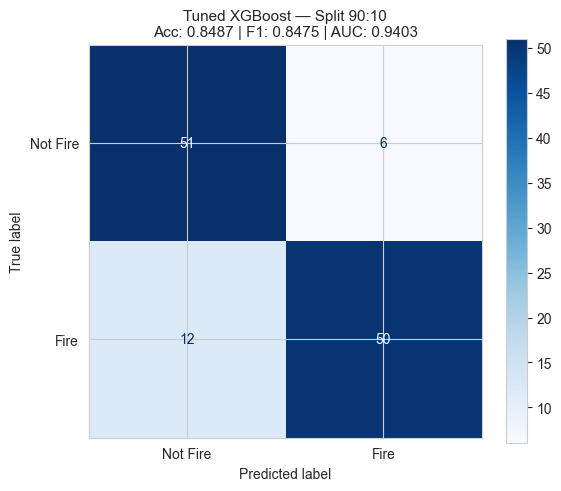

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_te_best, y_test_pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Fire', 'Fire'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(
    f'Tuned {best_model_name} — Split {best_split}\n'
    f'Acc: {tuned_test_acc:.4f} | F1: {tuned_test_f1:.4f} | AUC: {tuned_test_auc:.4f}',
    fontsize=11
)

plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance menunjukkan kontribusi relatif setiap fitur terhadap prediksi model. Hanya ditampilkan untuk model berbasis tree (Decision Tree, Random Forest, XGBoost).

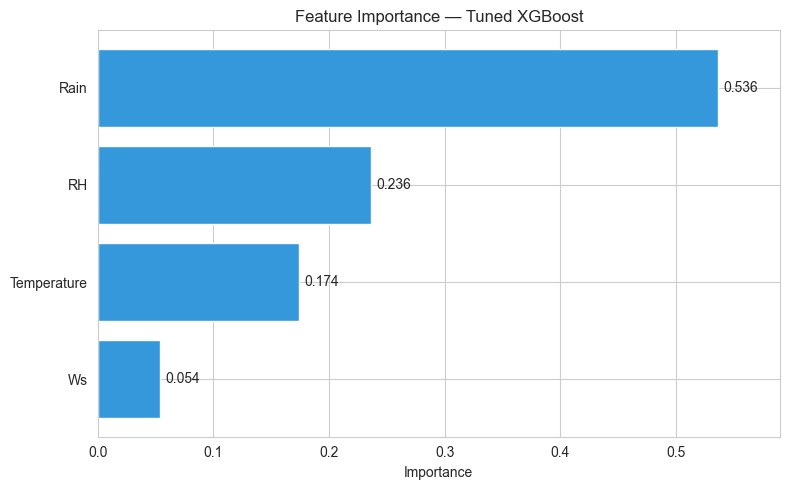


Feature Importance Ranking:
  Rain           : 0.5363
  RH             : 0.2359
  Temperature    : 0.1740
  Ws             : 0.0538


In [44]:
# Ambil feature importance dari tuned model
if hasattr(tuned_model, 'feature_importances_'):
    importances = tuned_model.feature_importances_
    feature_names = X.columns
    
    # Buat DataFrame
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color='#3498db')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — Tuned {best_model_name}', fontsize=12)
    ax.set_xlim(0, fi_df['Importance'].max() * 1.1)
    
    # Tampilkan nilai importance
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print('\nFeature Importance Ranking:')
    for _, row in fi_df.sort_values('Importance', ascending=False).iterrows():
        print(f'  {row["Feature"]:15s}: {row["Importance"]:.4f}')
else:
    print('Model tidak memiliki attribute feature_importances_')

## 8b. Threshold Tuning

ROC-AUC meningkat setelah tuning, tapi F1-score menurun. Ini menunjukkan bahwa **distribusi probabilitas model berubah** sehingga threshold default 0.5 sudah tidak optimal.

**Threshold tuning** mencari titik keputusan (threshold) optimal yang memberikan F1-score tertinggi. Berbeda dari ROC-AUC yang threshold-independent, F1-score sangat bergantung pada threshold.

THRESHOLD TUNING
Threshold default : 0.50
Threshold optimal : 0.21
F1 @ default      : 0.8475
F1 @ optimal      : 0.8652
Improvement       : +0.0178


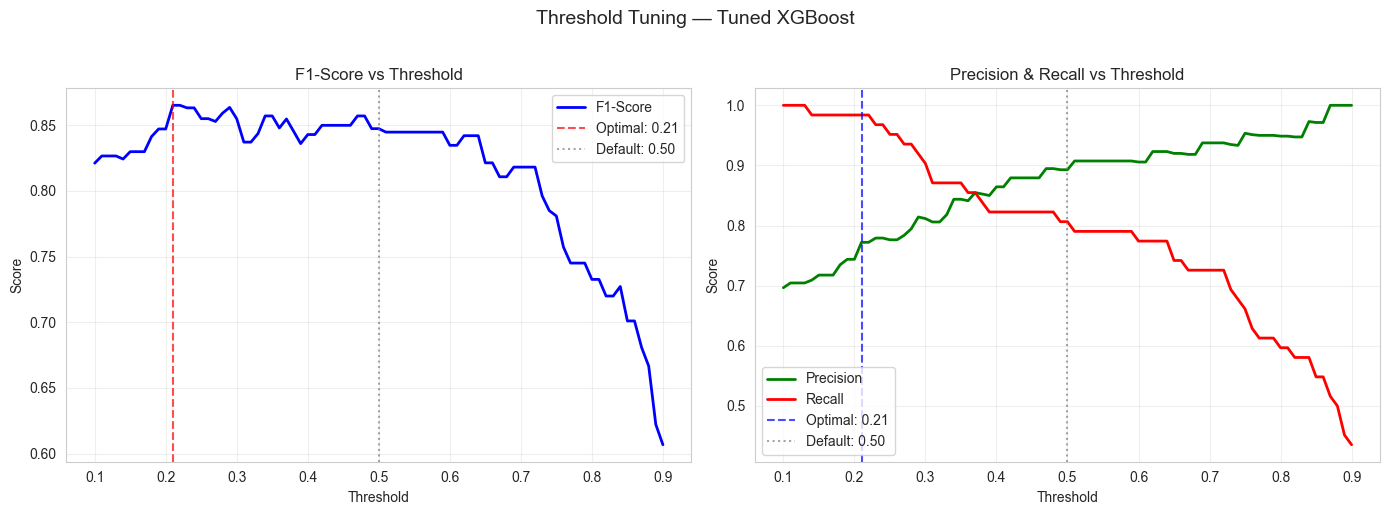

In [45]:
# Cari threshold optimal untuk F1-Score tertinggi
from sklearn.metrics import f1_score

# Probabilitas prediksi dari tuned model pada test set
y_proba = tuned_model.predict_proba(X_te_best)[:, 1]

# Test berbagai threshold dari 0.1 sampai 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []
prec_scores = []
rec_scores = []
acc_scores = []

for t in thresholds:
    y_pred_custom = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_te_best, y_pred_custom))
    prec_scores.append(precision_score(y_te_best, y_pred_custom))
    rec_scores.append(recall_score(y_te_best, y_pred_custom))
    acc_scores.append(accuracy_score(y_te_best, y_pred_custom))

# Threshold terbaik
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1_threshold = f1_scores[best_threshold_idx]

print('='*60)
print('THRESHOLD TUNING')
print('='*60)
print(f'Threshold default : 0.50')
print(f'Threshold optimal : {best_threshold:.2f}')
print(f'F1 @ default      : {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}')
print(f'F1 @ optimal      : {best_f1_threshold:.4f}')
print(f'Improvement       : {best_f1_threshold - f1_scores[np.argmin(np.abs(thresholds - 0.5))]:+.4f}')

# Plot F1 vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 vs Threshold
axes[0].plot(thresholds, f1_scores, 'b-', linewidth=2, label='F1-Score')
axes[0].axvline(x=best_threshold, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {best_threshold:.2f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default: 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('F1-Score vs Threshold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision & Recall vs Threshold
axes[1].plot(thresholds, prec_scores, 'g-', linewidth=2, label='Precision')
axes[1].plot(thresholds, rec_scores, 'r-', linewidth=2, label='Recall')
axes[1].axvline(x=best_threshold, color='b', linestyle='--', alpha=0.7, label=f'Optimal: {best_threshold:.2f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default: 0.50')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Threshold Tuning — Tuned {best_model_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

PERBANDINGAN THRESHOLD: DEFAULT (0.50) vs OPTIMAL (0.21)

   Metric Default (0.50) Optimal (0.21)   Delta
 Accuracy         0.8487         0.8403 -0.0084
Precision         0.8929         0.7722 -0.1207
   Recall         0.8065         0.9839 +0.1774
 F1-Score         0.8475         0.8652 +0.0178
  ROC-AUC         0.9403         0.9403  0.0000



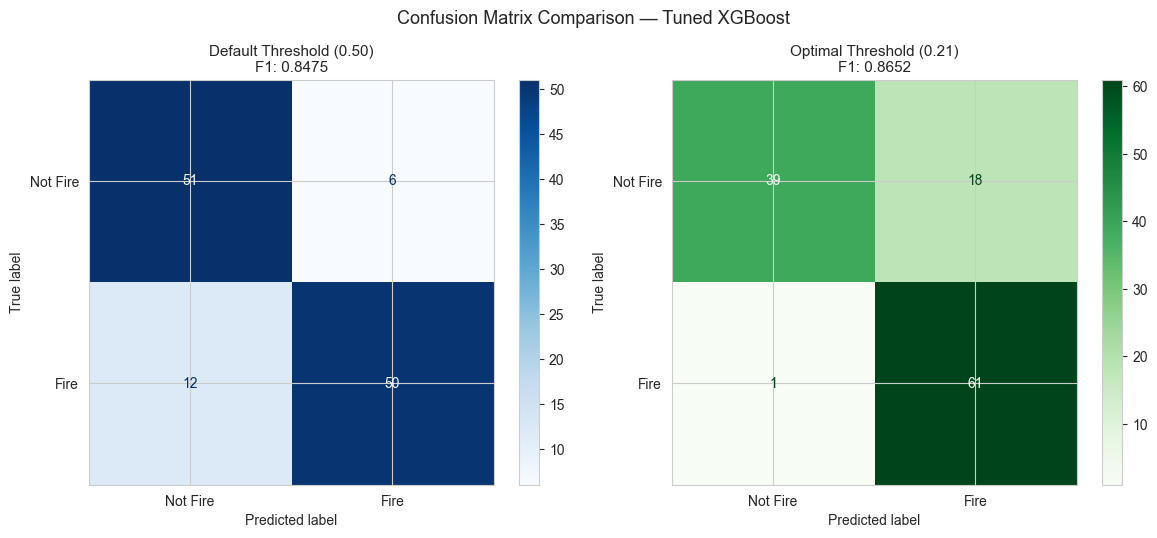


Kesimpulan: Threshold 0.21 memberikan F1-Score 0.8652
(vs default 0.50: F1 = 0.8475, selisih = +0.0178)


In [46]:
# Prediksi dengan threshold optimal
y_pred_optimal = (y_proba >= best_threshold).astype(int)

# Metrik dengan threshold optimal
optimal_acc = accuracy_score(y_te_best, y_pred_optimal)
optimal_prec = precision_score(y_te_best, y_pred_optimal)
optimal_rec = recall_score(y_te_best, y_pred_optimal)
optimal_f1 = f1_score(y_te_best, y_pred_optimal)
optimal_auc = roc_auc_score(y_te_best, y_proba)  # AUC tetap sama (threshold-independent)

# Metrik dengan threshold default (0.5)
y_pred_default = (y_proba >= 0.5).astype(int)
default_acc = accuracy_score(y_te_best, y_pred_default)
default_prec = precision_score(y_te_best, y_pred_default)
default_rec = recall_score(y_te_best, y_pred_default)
default_f1 = f1_score(y_te_best, y_pred_default)

# Tabel perbandingan
threshold_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Default (0.50)': [
        f'{default_acc:.4f}', f'{default_prec:.4f}',
        f'{default_rec:.4f}', f'{default_f1:.4f}',
        f'{optimal_auc:.4f}'
    ],
    f'Optimal ({best_threshold:.2f})': [
        f'{optimal_acc:.4f}', f'{optimal_prec:.4f}',
        f'{optimal_rec:.4f}', f'{optimal_f1:.4f}',
        f'{optimal_auc:.4f}'
    ],
    'Delta': [
        f'{optimal_acc - default_acc:+.4f}',
        f'{optimal_prec - default_prec:+.4f}',
        f'{optimal_rec - default_rec:+.4f}',
        f'{optimal_f1 - default_f1:+.4f}',
        '0.0000'
    ]
})

print('='*70)
print(f'PERBANDINGAN THRESHOLD: DEFAULT (0.50) vs OPTIMAL ({best_threshold:.2f})')
print('='*70)
print()
print(threshold_comparison.to_string(index=False))
print()

# Confusion Matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CM Default
cm_default = confusion_matrix(y_te_best, y_pred_default)
disp_default = ConfusionMatrixDisplay(cm_default, display_labels=['Not Fire', 'Fire'])
disp_default.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Default Threshold (0.50)\nF1: {default_f1:.4f}', fontsize=11)

# CM Optimal
cm_optimal = confusion_matrix(y_te_best, y_pred_optimal)
disp_optimal = ConfusionMatrixDisplay(cm_optimal, display_labels=['Not Fire', 'Fire'])
disp_optimal.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Optimal Threshold ({best_threshold:.2f})\nF1: {optimal_f1:.4f}', fontsize=11)

plt.suptitle(f'Confusion Matrix Comparison — Tuned {best_model_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nKesimpulan: Threshold {best_threshold:.2f} memberikan F1-Score {optimal_f1:.4f}')
print(f'(vs default 0.50: F1 = {default_f1:.4f}, selisih = {optimal_f1 - default_f1:+.4f})')

## 9. Cross-Validation — Tuned Model

Cross-validation 5-fold pada tuned model dengan seluruh data (X, y). Digunakan untuk mendapatkan estimasi performa yang lebih robust.

In [47]:
print(f'=== CROSS-VALIDATION (5-Fold Stratified) — Tuned {best_model_name} ===')
print()

# Definisi scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation untuk setiap metrik
tuned_cv_results = {}
for metric_name, metric_scorer in scoring.items():
    scores = cross_val_score(tuned_model, X, y, cv=skf, scoring=metric_scorer)
    tuned_cv_results[metric_name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f'  {metric_name:>12}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print(f'              Fold scores: {[f"{s:.4f}" for s in scores]}')

# Tabel ringkasan
print('\n=== RINGKASAN CV TUNED MODEL ===')
tuned_cv_df = pd.DataFrame({
    'Metric': list(tuned_cv_results.keys()),
    'Mean': [v['mean'] for v in tuned_cv_results.values()],
    'Std': [v['std'] for v in tuned_cv_results.values()]
})
tuned_cv_df['Mean (%)'] = (tuned_cv_df['Mean'] * 100).round(2)
tuned_cv_df['Std (%)'] = (tuned_cv_df['Std'] * 100).round(2)
print(tuned_cv_df[['Metric', 'Mean (%)', 'Std (%)']].to_string(index=False))

# Bandingkan dengan CV baseline (jika ada)
print('\n=== PERBANDINGAN CV: BASELINE vs TUNED ===')
compare_cv = pd.DataFrame({
    'Metric': list(cv_results.keys()),
    'Baseline Mean (%)': [f"{v['mean']*100:.2f}" for v in cv_results.values()],
    'Tuned Mean (%)': [f"{v*100:.2f}" for v in tuned_cv_df['Mean']],
})
print(compare_cv.to_string(index=False))

=== CROSS-VALIDATION (5-Fold Stratified) — Tuned XGBoost ===



      accuracy: 0.8476 (+/- 0.0259)
              Fold scores: ['0.8697', '0.8235', '0.8739', '0.8608', '0.8101']


     precision: 0.8581 (+/- 0.0246)
              Fold scores: ['0.8974', '0.8475', '0.8730', '0.8462', '0.8264']


        recall: 0.8482 (+/- 0.0378)
              Fold scores: ['0.8468', '0.8065', '0.8871', '0.8943', '0.8065']


            f1: 0.8527 (+/- 0.0260)
              Fold scores: ['0.8714', '0.8264', '0.8800', '0.8696', '0.8163']


       roc_auc: 0.9166 (+/- 0.0248)
              Fold scores: ['0.9314', '0.8872', '0.9515', '0.9233', '0.8895']

=== RINGKASAN CV TUNED MODEL ===
   Metric  Mean (%)  Std (%)
 accuracy     84.76     2.59
precision     85.81     2.46
   recall     84.82     3.78
       f1     85.27     2.60
  roc_auc     91.66     2.48

=== PERBANDINGAN CV: BASELINE vs TUNED ===
   Metric Baseline Mean (%) Tuned Mean (%)
 accuracy             82.66          84.76
precision             82.43          85.81
   recall             84.82          84.82
       f1             83.59          85.27
  roc_auc             90.41          91.66


## 10. Kesimpulan Hyperparameter Tuning

### Parameter Terbaik
Hasil **RandomizedSearchCV** (100 iterasi, 5-fold stratified CV, scoring F1):

| Parameter | Nilai |
|-----------|-------|
| `n_estimators` | 150 |
| `max_depth` | 5 |
| `learning_rate` | 0.05 |
| `min_child_weight` | 9 |
| `subsample` | 0.7 |
| `colsample_bytree` | 0.7 |
| `gamma` | 0.2 |
| `reg_alpha` / `reg_lambda` | 1 / 1 |

**Best CV F1**: **0.8576**

### Peningkatan Performa
Perbandingan berbasis **5-fold cross-validation** (lebih robust daripada single split):

| Metrik | Baseline | Tuned | Peningkatan |
|--------|----------|-------|-------------|
| Test F1 | 83.59% | 85.27% | +1.68% |
| Test Acc | 82.66% | 84.76% | +2.10% |
| ROC-AUC | 90.41% | 91.66% | +1.25% |

Pada single split 90:10, AUC naik dari **0.9219 → 0.9403** (+0.0184), sementara F1 bergeser (0.8667 → 0.8475) akibat perubahan distribusi probabilitas — dipulihkan lewat **threshold tuning**.

### Analisis
1. **Overfitting**: gap accuracy turun dari **3.16% → 2.22%** dan gap F1 dari **3.62% → 2.89%** setelah tuning — model tetap *Good Fit* dan lebih generalisasi.
2. **Parameter Penting**: tuning menambah regularisasi (`subsample=0.7`, `colsample_bytree=0.7`, `reg_alpha/lambda=1`) sehingga gap train-test mengecil; `min_child_weight=9` turut memperkuat generalisasi.
3. **Feature Importance**: **Rain (0.5363)** paling dominan, disusul **RH (0.2359)** — keduanya menyumbang **77.2%**; sisanya Temperature (0.1740) dan Ws (0.0538).

### Threshold Tuning
Distribusi probabilitas tuned model berubah sehingga threshold optimal turun ke **0.21**: F1 naik **0.8475 → 0.8652** (+0.0178) dengan recall **0.9839** (hampir semua kasus fire terdeteksi).

### Model Akhir
Model akhir yang direkomendasikan: **Tuned XGBoost** (XGBoost tuning + threshold 0.21)

## 11. Export Model untuk Deployment

Untuk diintegrasikan ke aplikasi **Early Warning System**, model terbaik (tuned XGBoost), threshold optimal, dan metadatanya disimpan ke `models/xgboost_tuned.joblib`. Artefak inilah yang nanti dimuat oleh `src/karhutla/predict.py` (dan API di masa depan) tanpa perlu melatih ulang.

In [48]:
import joblib
from pathlib import Path

# Deteksi akar repositori secara otomatis
repo_root = Path.cwd()
while not (repo_root / 'data').is_dir():
    repo_root = repo_root.parent

model_metadata = {
    "model": tuned_model,
    "model_type": "XGBoost (tuned)",
    "features": X.columns.tolist(),
    "threshold": float(best_threshold),
    "best_params": random_search.best_params_,
    "cv_f1_best": float(random_search.best_score_),
    "metrics_split": {
        "split": best_split,
        "test_f1": tuned_test_f1,
        "test_acc": tuned_test_acc,
        "test_auc": tuned_test_auc,
        "test_precision": tuned_test_prec,
        "test_recall": tuned_test_rec,
    },
    "n_samples": int(len(X)),
    "n_features": int(X.shape[1]),
}

model_dir = repo_root / 'models'
model_dir.mkdir(exist_ok=True)
model_path = model_dir / 'xgboost_tuned.joblib'
joblib.dump(model_metadata, model_path)

print(f'Artefak model tersimpan di: {model_path}')
print(f'  - Model        : {model_metadata["model_type"]}')
print(f'  - Fitur        : {", ".join(model_metadata["features"])}')
print(f'  - Threshold    : {model_metadata["threshold"]}')
print(f'  - Best CV F1   : {model_metadata["cv_f1_best"]:.4f}')
print(f'  - Test F1      : {model_metadata["metrics_split"]["test_f1"]:.4f}')
print(f'  - Test AUC     : {model_metadata["metrics_split"]["test_auc"]:.4f}')

Artefak model tersimpan di: C:\Users\ihram\Documents\Iamfolder\project\mbkm_project\deteksi_karhutlav2\models\xgboost_tuned.joblib
  - Model        : XGBoost (tuned)
  - Fitur        : Temperature, Ws, Rain, RH
  - Threshold    : 0.20999999999999996
  - Best CV F1   : 0.8576
  - Test F1      : 0.8475
  - Test AUC     : 0.9403
